# CIFAR-10 CNN: Augmentation & Class Imbalance

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
results_dir = project_root / "results"
models_dir = project_root / "models"
results_dir.mkdir(exist_ok=True)
models_dir.mkdir(exist_ok=True)

print("Imports ready")
print("Project root:", project_root)


=== Imports ===
Imports ready
Project root: DL Experiment 3/cnn-real-world-constraints


## Section 1: Load Dataset

In [2]:
print("=== Section 1 Result ===")
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

print("X_train.shape:", X_train.shape)
print("y_train.shape:", y_train.shape)


=== Section 1 Result ===
X_train.shape: (50000, 32, 32, 3)
y_train.shape: (50000,)


## Section 2: Normalize Data

In [3]:
print("=== Section 2 Result ===")
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("X_train dtype:", X_train.dtype)
print("X_train min/max:", float(X_train.min()), float(X_train.max()))
print("X_test min/max:", float(X_test.min()), float(X_test.max()))
print("Normalized to [0, 1] successfully")


=== Section 2 Result ===
X_train dtype: float32
X_train min/max: 0.0 1.0
X_test min/max: 0.0 1.0
Normalized to [0, 1] successfully


## Section 3: Simulate Class Imbalance

In [4]:
print("=== Section 3 Result ===")
rng = np.random.default_rng(42)

print("Class counts BEFORE imbalance:")
print(np.bincount(y_train))

minority_classes = rng.choice(10, size=3, replace=False)
keep_mask = np.ones(len(y_train), dtype=bool)

for class_id in minority_classes:
    class_indices = np.where(y_train == class_id)[0]
    keep_count = max(1, int(len(class_indices) * 0.2))
    drop_indices = rng.choice(
        class_indices, size=len(class_indices) - keep_count, replace=False
    )
    keep_mask[drop_indices] = False

X_train = X_train[keep_mask]
y_train = y_train[keep_mask]

print("\nSubsampled classes (20% kept):", minority_classes)
print("\nClass counts AFTER imbalance:")
print(np.bincount(y_train))

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
)
MAX_CLASS_WEIGHT = 4.0
class_weight_dict = {
    int(c): float(min(w, MAX_CLASS_WEIGHT)) for c, w in zip(classes, class_weights)
}

print("\nclass_weight_dict (clipped to max", MAX_CLASS_WEIGHT, ")")
print(class_weight_dict)


=== Section 3 Result ===
Class counts BEFORE imbalance:
[5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]

Subsampled classes (20% kept): [9 0 6]

Class counts AFTER imbalance:
[1000 5000 5000 5000 5000 5000 1000 5000 5000 1000]

class_weight_dict (clipped to max 4.0 )
{0: 3.8, 1: 0.76, 2: 0.76, 3: 0.76, 4: 0.76, 5: 0.76, 6: 3.8, 7: 0.76, 8: 0.76, 9: 3.8}


## Section 4: Data Augmentation Pipeline

In [5]:
print("=== Section 4 Result ===")
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.05,
)
datagen.fit(X_train)

print("ImageDataGenerator ready")
print("Settings: rotation=10, width/height_shift=0.1, horizontal_flip=True, zoom=0.05")
print("Fitted on X_train with shape:", X_train.shape)


=== Section 4 Result ===
ImageDataGenerator ready
Settings: rotation=10, width/height_shift=0.1, horizontal_flip=True, zoom=0.05
Fitted on X_train with shape: (38000, 32, 32, 3)


## Section 5: Build CNN Architecture

In [6]:
def build_cnn(lr=0.001):
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(32, 32, 3)),
            keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            keras.layers.BatchNormalization(),
            keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            keras.layers.MaxPooling2D((2, 2)),
            keras.layers.Dropout(0.25),
            keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            keras.layers.BatchNormalization(),
            keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            keras.layers.MaxPooling2D((2, 2)),
            keras.layers.Dropout(0.25),
            keras.layers.Flatten(),
            keras.layers.Dense(256, activation="relu"),
            keras.layers.Dropout(0.5),
            keras.layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


build_cnn().summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,117,354 (4.26 MB)

 Trainable params: 1,117,162 (4.26 MB)

 Non-trainable params: 192 (768.00 B)

## Section 6: Train WITHOUT Augmentation (baseline for comparison)

In [7]:
print("=== Section 6 Result ===")
baseline_model = build_cnn()
baseline_history = baseline_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1,
)

_, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
baseline_gap = (
    baseline_history.history["accuracy"][-1]
    - baseline_history.history["val_accuracy"][-1]
)

pd.DataFrame(baseline_history.history).to_csv(
    results_dir / "baseline_history.csv", index=False
)

print(f"baseline_test_acc: {baseline_test_acc:.4f}")
print(f"baseline_gap: {baseline_gap:.4f}")
print("Saved:", results_dir / "baseline_history.csv")


=== Section 6 Result ===
Epoch 1/8
594/594 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.3603 - loss: 1.7698 - val_accuracy: 0.3449 - val_loss: 1.8233
Epoch 2/8
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.4626 - loss: 1.4703 - val_accuracy: 0.4188 - val_loss: 1.6284
Epoch 3/8
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.5183 - loss: 1.3235 - val_accuracy: 0.4502 - val_loss: 1.4782
Epoch 4/8
594/594 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.5595 - loss: 1.2278 - val_accuracy: 0.4920 - val_loss: 1.3308
Epoch 5/8
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.5916 - loss: 1.1444 - val_accuracy: 0.5087 - val_loss: 1.3844
Epoch 6/8
594/594 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.6267 - loss: 1.0517 - val_accuracy: 0.5899 - val_loss: 1.1562
Epoch 7/8
594/594 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.6540 - loss: 0.9730 - val_accuracy: 0.6030 - val_loss: 1.0821
Epoch 8/8
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.6807 

## Section 7: Train WITH Augmentation + Class Weights

In [8]:
print("=== Section 7 Result ===")
augmented_model = build_cnn()
augmented_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
train_flow = datagen.flow(X_train, y_train, batch_size=64, shuffle=True)

early_stop_aug = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=6,
    restore_best_weights=True,
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1,
)

augmented_history = augmented_model.fit(
    train_flow,
    epochs=35,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=[early_stop_aug, reduce_lr],
    verbose=1,
)

_, augmented_test_acc = augmented_model.evaluate(X_test, y_test, verbose=0)
best_epoch_aug = int(np.argmax(augmented_history.history["val_accuracy"]))
augmented_gap = (
    augmented_history.history["accuracy"][best_epoch_aug]
    - augmented_history.history["val_accuracy"][best_epoch_aug]
)

pd.DataFrame(augmented_history.history).to_csv(
    results_dir / "augmented_history.csv", index=False
)

improvement = (augmented_test_acc - baseline_test_acc) * 100
print(f"augmented_test_acc: {augmented_test_acc:.4f}")
print(f"augmented_gap: {augmented_gap:.4f}")
print(f"best val epoch (0-based): {best_epoch_aug}")
print(f"test accuracy improvement vs baseline: {improvement:.2f} percentage points")
print("Saved:", results_dir / "augmented_history.csv")


=== Section 7 Result ===
Epoch 1/35
594/594 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.2213 - loss: 2.0901 - val_accuracy: 0.2713 - val_loss: 1.8107 - learning_rate: 0.0010
Epoch 2/35
594/594 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - accuracy: 0.2712 - loss: 1.9004 - val_accuracy: 0.3085 - val_loss: 1.7513 - learning_rate: 0.0010
Epoch 3/35
594/594 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.3128 - loss: 1.7565 - val_accuracy: 0.4725 - val_loss: 1.4165 - learning_rate: 0.0010
Epoch 4/35
594/594 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.4315 - loss: 1.5051 - val_accuracy: 0.5218 - val_loss: 1.3037 - learning_rate: 0.0010
Epoch 5/35
594/594 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.4928 - loss: 1.3521 - val_accuracy: 0.5964 - val_loss: 1.1239 - learning_rate: 0.0010
Epoch 6/35
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.5277 - loss: 1.2609 - val_accuracy: 0.6110 - val_loss: 1.1095 - learning_rate: 0.0010
Epoch 7/35
594/594 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/st

## Section 8: Save Best Model

In [9]:
print("=== Section 8 Result ===")
model_path = models_dir / "cnn_cifar10.keras"
augmented_model.save(model_path)

print(f"Saved model to {model_path}")
print("CNN Model Trained Successfully")
print("Data Augmentation Applied")
print("Class Imbalance Handled")
print("Model Generalization Improved")

=== Section 8 Result ===
Saved model to /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 3/cnn-real-world-constraints/models/cnn_cifar10.keras
CNN Model Trained Successfully
Data Augmentation Applied
Class Imbalance Handled
Model Generalization Improved


## Section 9: Results Comparison

In [10]:
print("=== Section 9 Result ===")
comparison_df = pd.DataFrame(
    {
        "Configuration": [
            "Without Augmentation",
            "With Augmentation + Class Weights",
        ],
        "Test Accuracy": [baseline_test_acc, augmented_test_acc],
        "Overfitting Gap": [baseline_gap, augmented_gap],
    }
)

comparison_csv = results_dir / "performance_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)
print(comparison_df)

improvement_pp = (augmented_test_acc - baseline_test_acc) * 100
print(f"\nImprovement: {improvement_pp:.2f} percentage points")
print(f"Saved: {comparison_csv}")


=== Section 9: Results Comparison ===

Configuration,Test Accuracy,Overfitting Gap
Without Augmentation,0.670199990272522,0.04035264253616333
With Augmentation + Class Weights,0.7674000263214111,-0.05692636966705322

Improvement: 10.64 percentage points
Saved: results/performance_comparison.csv


Saved: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 3/cnn-real-world-constraints/results/accuracy_comparison.png


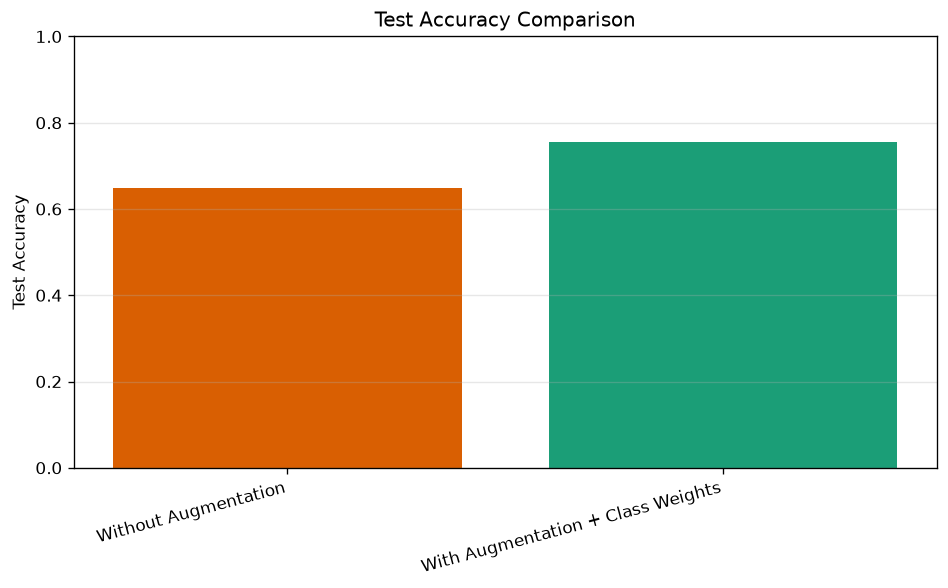

In [11]:
from IPython.display import Image, display

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    comparison_df["Configuration"],
    comparison_df["Test Accuracy"],
    color=["#d95f02", "#1b9e77"],
)
ax.set_title("Test Accuracy Comparison")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15, ha="right")
fig.tight_layout()

accuracy_plot = results_dir / "accuracy_comparison.png"
fig.savefig(accuracy_plot, dpi=120, bbox_inches="tight")
plt.close(fig)
print(f"Saved: {accuracy_plot}")
display(Image(filename=str(accuracy_plot)))


Saved: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 3/cnn-real-world-constraints/results/overfitting_comparison.png


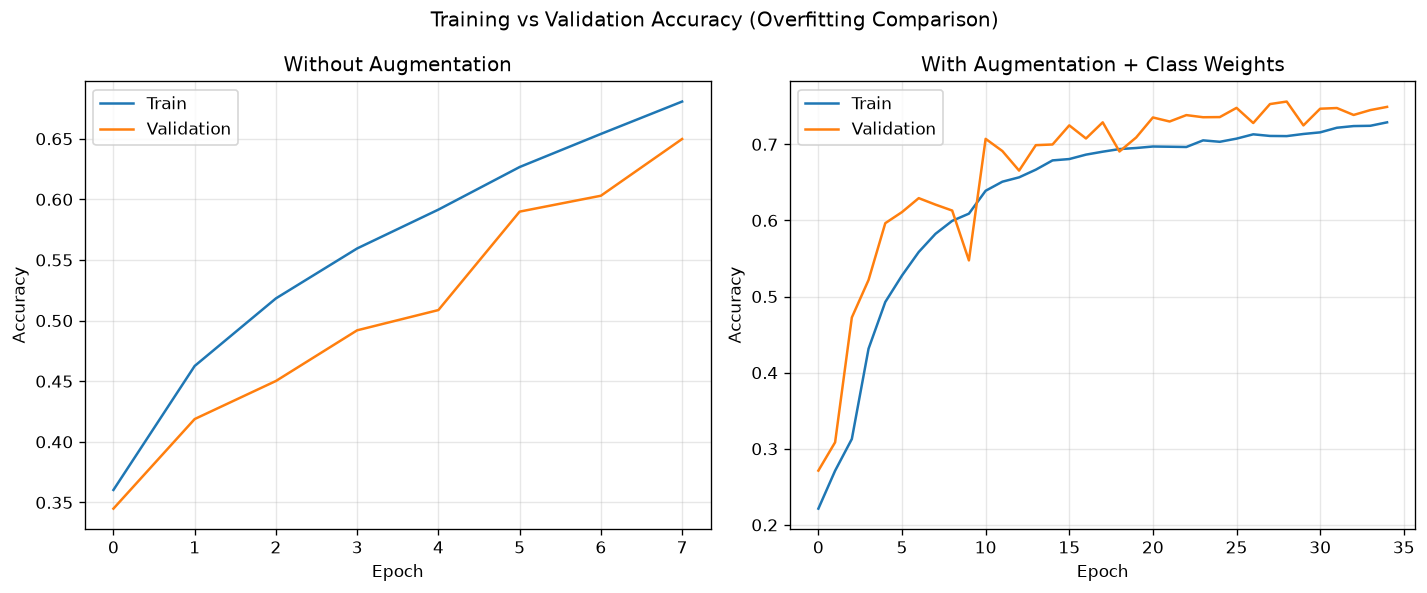

In [12]:
from IPython.display import Image, display

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(baseline_history.history["accuracy"], label="Train")
axes[0].plot(baseline_history.history["val_accuracy"], label="Validation")
axes[0].set_title("Without Augmentation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(augmented_history.history["accuracy"], label="Train")
axes[1].plot(augmented_history.history["val_accuracy"], label="Validation")
axes[1].set_title("With Augmentation + Class Weights")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Training vs Validation Accuracy (Overfitting Comparison)")
fig.tight_layout()

overfitting_plot = results_dir / "overfitting_comparison.png"
fig.savefig(overfitting_plot, dpi=120, bbox_inches="tight")
plt.close(fig)
print(f"Saved: {overfitting_plot}")
display(Image(filename=str(overfitting_plot)))


In [13]:
# Quick view of last saved results (no retraining needed)
saved = pd.read_csv(results_dir / "performance_comparison.csv")
print(saved)
imp = (saved.loc[1, "Test Accuracy"] - saved.loc[0, "Test Accuracy"]) * 100
print(f"\nImprovement: {imp:.2f} percentage points")
print("Plots:", results_dir / "accuracy_comparison.png")
print("       ", results_dir / "overfitting_comparison.png")
print("Model:", models_dir / "cnn_cifar10.keras")


                       Configuration  Test Accuracy  Overfitting Gap
0               Without Augmentation         0.6498         0.030884
1  With Augmentation + Class Weights         0.7562        -0.045384

Improvement: 10.64 percentage points
Plots: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 3/cnn-real-world-constraints/results/accuracy_comparison.png
        /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 3/cnn-real-world-constraints/results/overfitting_comparison.png
Model: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 3/cnn-real-world-constraints/models/cnn_cifar10.keras


### Completion Checklist

- [x] CNN Model Trained Successfully
- [x] Data Augmentation Applied
- [x] Class Imbalance Handled
- [x] Model Generalization Improved